# 1. 通信入门

**Introduction to Communication**

---

本notebook是通信基础系列的第一课，将帮助您建立对通信系统的整体认识。从烽火台到5G，通信技术经历了漫长的发展历程，但其核心原理始终围绕一个基本问题：**如何将信息可靠地从一处传递到另一处？**

理解通信的基本概念和系统架构，是学习OTFS等先进调制技术的基础。

## 1. 学习目标

通过本notebook，您将：

- **理解通信的基本定义和重要性**：掌握什么是通信，为什么它在现代社会中不可或缺
- **了解通信系统的基本组成**：理解发射机、信道、接收机的完整链路
- **了解通信行业的发展历程**：从莫尔斯电码到5G的历史演进
- **掌握通信系统的资源约束**：带宽、功率等基本限制因素
- **认识基本的性能指标**：信噪比（SNR）、误码率（BER）等

## 2. 概念讲解

### 2.1 什么是通信？

**通信**（Communication）是指信息从发送端（信源）到接收端（信宿）的传递过程。现代通信系统利用电磁波作为载体的无线通信，已经渗透到我们生活的方方面面。

**历史回顾：从烽火台到5G**

| 时代 | 技术 | 特点 |
|------|------|------|
| 古代 | 烽火台、旗语、信鸽 | 视觉/生物方式，距离有限 |
| 19世纪 | 电报（莫尔斯电码） | 电气方式，数字通信开端 |
| 20世纪初 | 电话、无线电 | 语音通信，无线传输 |
| 20世纪中 | 模拟电视、移动电话 | 多媒体通信，移动通信萌芽 |
| 20世纪末 | 数字通信、2G/3G | 数字化，移动互联网兴起 |
| 21世纪 | 4G LTE、WiFi | 宽带移动互联，视频时代 |
| 当代 | 5G、卫星互联网、IoT | 万物互联，超低时延 |

### 2.2 通信系统的基本架构

一个完整的通信系统由三大组成部分：

```
发射机 → 信道 → 接收机
```

**1. 发射机（Transmitter）**
- 信源编码：压缩数据，去除冗余
- 信道编码：添加冗余，实现纠错
- 调制：将基带信号加载到载波上
- 功率放大：增强信号发射功率

**2. 信道（Channel）**
- 无线信道：自由空间传播，存在衰减和多径
- 有线信道：光纤、电缆等，较为稳定
- 噪声和干扰：热噪声、邻道干扰等

**3. 接收机（Receiver）**
- 低噪放：放大信号同时尽量抑制噪声
- 解调：恢复基带信号
- 信道解码：利用冗余检测和纠正错误
- 信源解码：恢复原始数据

### 2.3 现代通信应用场景

现代通信技术涵盖多种应用场景：

| 应用场景 | 关键技术 | 典型指标 |
|----------|----------|----------|
| **移动通信** | 4G LTE, 5G NR | 峰值速率 100Mbps-10Gbps |
| **卫星通信** | Ka/Ku波段 | 全球覆盖，高通量 |
| **WiFi** | IEEE 802.11ax | 室内覆盖，多用户MIMO |
| **物联网(IoT)** | LoRa, NB-IoT | 低功耗，广覆盖 |
| **车联网(V2X)** | C-V2X | 超低时延，高可靠性 |

### 2.4 通信的基本问题

香农（Shannon）在1948年提出了通信系统的基本理论框架。任何通信系统都面临三个基本问题：

1. **传输可靠性**：如何在噪声干扰下准确传递信息？
2. **传输效率**：如何在有限的资源下传输更多信息？
3. **安全性**：如何确保信息只被授权用户接收？

香农给出了这些问题的理论极限，但实际系统需要在复杂度、性能和成本之间做出权衡。

## 3. Python演示：无线通信链路

下面我们使用Python构建一个简单的无线通信链路，直观展示通信系统的基本组成。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 设置中文字体支持，确保图表中能正确显示中文
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("无线通信链路演示环境已准备就绪")

无线通信链路演示环境已准备就绪


### 3.1 绘制无线通信链路框图

C:\Users\bigma\AppData\Local\Temp\ipykernel_32600\3658807126.py:90: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) SimHei.
  plt.tight_layout()
f:\MyDocuments\project-github\Fundamental-Communication\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


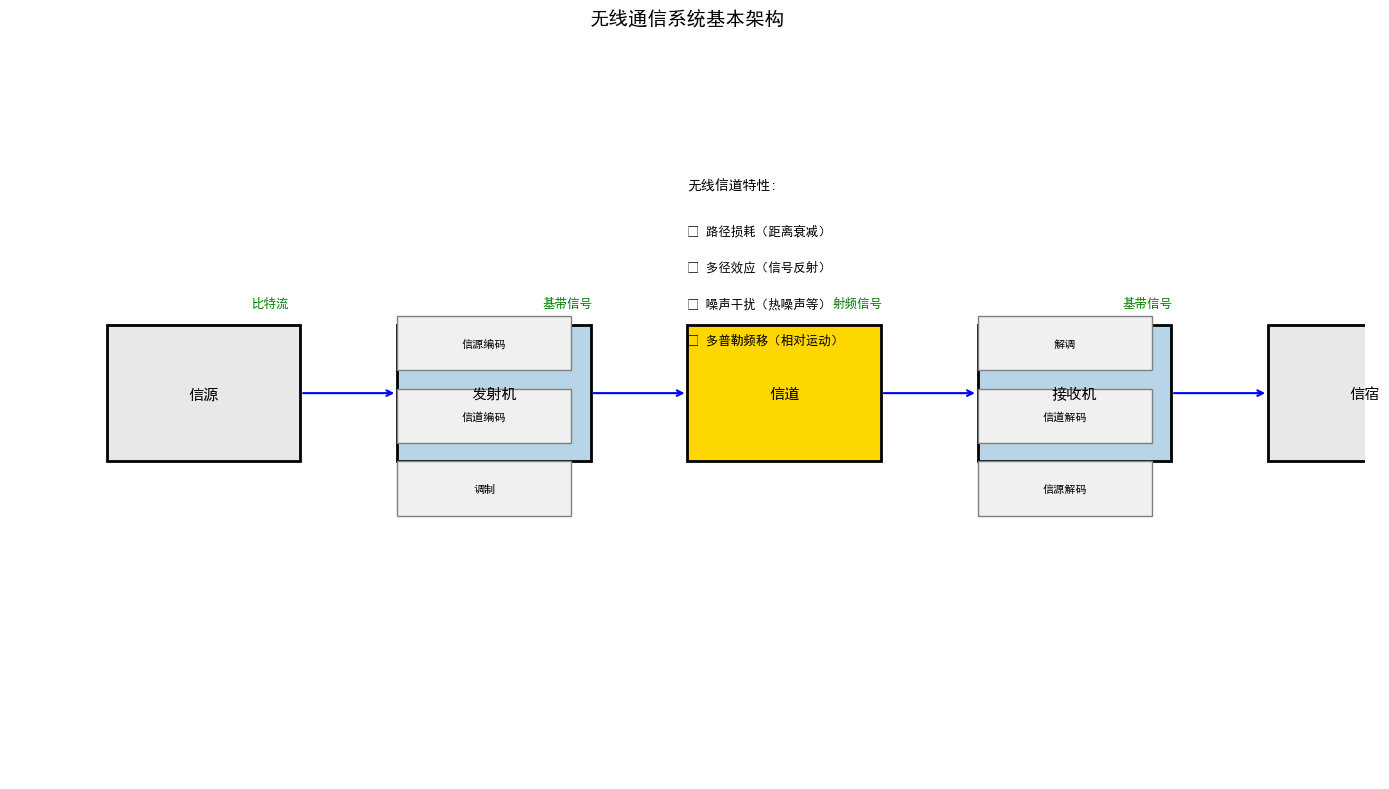

In [2]:
# 绘制无线通信链路框图
# 此函数展示通信系统的基本架构：信源 → 发射机 → 信道 → 接收机 → 信宿
def draw_radio_link_diagram():
    """
    绘制无线通信系统框图
    展示发射机和接收机的内部结构，包括信源/信道编码、调制/解调等模块
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 8)
    ax.axis('off')
    
    # 定义框图元素（位置、宽度、高度、标签、颜色）
    boxes = [
        {'pos': (1, 3.5), 'w': 2, 'h': 1.5, 'text': '信源', 'color': '#E8E8E8'},
        {'pos': (4, 3.5), 'w': 2, 'h': 1.5, 'text': '发射机', 'color': '#B8D4E8'},
        {'pos': (7, 3.5), 'w': 2, 'h': 1.5, 'text': '信道', 'color': '#FFD700'},
        {'pos': (10, 3.5), 'w': 2, 'h': 1.5, 'text': '接收机', 'color': '#B8D4E8'},
        {'pos': (13, 3.5), 'w': 2, 'h': 1.5, 'text': '信宿', 'color': '#E8E8E8'}
    ]
    
    # 发射机内部结构：信源编码、信道编码、调制
    tx_blocks = [
        {'pos': (4, 4.5), 'w': 1.8, 'h': 0.6, 'text': '信源编码'},
        {'pos': (4, 3.7), 'w': 1.8, 'h': 0.6, 'text': '信道编码'},
        {'pos': (4, 2.9), 'w': 1.8, 'h': 0.6, 'text': '调制'},
    ]
    
    # 接收机内部结构：解调、信道解码、信源解码
    rx_blocks = [
        {'pos': (10, 4.5), 'w': 1.8, 'h': 0.6, 'text': '解调'},
        {'pos': (10, 3.7), 'w': 1.8, 'h': 0.6, 'text': '信道解码'},
        {'pos': (10, 2.9), 'w': 1.8, 'h': 0.6, 'text': '信源解码'},
    ]
    
    # 绘制主框（信源、发射机、信道、接收机、信宿）
    for box in boxes:
        rect = plt.Rectangle(box['pos'], box['w'], box['h'],
                           linewidth=2, edgecolor='black',
                           facecolor=box['color'], zorder=2)
        ax.add_patch(rect)
        ax.text(box['pos'][0] + box['w']/2, box['pos'][1] + box['h']/2,
               box['text'], ha='center', va='center', fontsize=11,
               fontweight='bold', zorder=3)
    
    # 绘制发射机内部模块
    for block in tx_blocks:
        rect = plt.Rectangle(block['pos'], block['w'], block['h'],
                           linewidth=1, edgecolor='gray',
                           facecolor='#F0F0F0', zorder=2)
        ax.add_patch(rect)
        ax.text(block['pos'][0] + block['w']/2, block['pos'][1] + block['h']/2,
               block['text'], ha='center', va='center', fontsize=8, zorder=3)
    
    # 绘制接收机内部模块
    for block in rx_blocks:
        rect = plt.Rectangle(block['pos'], block['w'], block['h'],
                           linewidth=1, edgecolor='gray',
                           facecolor='#F0F0F0', zorder=2)
        ax.add_patch(rect)
        ax.text(block['pos'][0] + block['w']/2, block['pos'][1] + block['h']/2,
               block['text'], ha='center', va='center', fontsize=8, zorder=3)
    
    # 绘制箭头连接线（表示信号流向）
    arrow_props = dict(arrowstyle='->', color='blue', lw=1.5)
    
    # 信源→发射机
    ax.annotate('', xy=(4, 4.25), xytext=(3, 4.25), arrowprops=arrow_props)
    # 发射机→信道
    ax.annotate('', xy=(7, 4.25), xytext=(6, 4.25), arrowprops=arrow_props)
    # 信道→接收机
    ax.annotate('', xy=(10, 4.25), xytext=(9, 4.25), arrowprops=arrow_props)
    # 接收机→信宿
    ax.annotate('', xy=(13, 4.25), xytext=(12, 4.25), arrowprops=arrow_props)
    
    # 添加信道特性标注（无线信道的主要影响因素）
    ax.text(7, 6.5, '无线信道特性:', fontsize=10, fontweight='bold')
    ax.text(7, 6.0, '• 路径损耗（距离衰减）', fontsize=9)
    ax.text(7, 5.6, '• 多径效应（信号反射）', fontsize=9)
    ax.text(7, 5.2, '• 噪声干扰（热噪声等）', fontsize=9)
    ax.text(7, 4.8, '• 多普勒频移（相对运动）', fontsize=9)
    
    # 添加信号流标注（各阶段信号形式）
    ax.text(2.5, 5.2, '比特流', fontsize=9, color='green')
    ax.text(5.5, 5.2, '基带信号', fontsize=9, color='green')
    ax.text(8.5, 5.2, '射频信号', fontsize=9, color='green')
    ax.text(11.5, 5.2, '基带信号', fontsize=9, color='green')
    
    ax.set_title('无线通信系统基本架构', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

draw_radio_link_diagram()

### 3.2 信号从发射到接收的流程演示

In [3]:
# 演示信号从发射到接收的完整流程
def simulate_simple_link():
    """
    简单的无线通信链路仿真
    展示：信源 → 信源编码 → 信道编码 → 调制 → 信道 → 解调 → 信宿
    
    参数说明：
    - fs: 采样率 (Hz)
    - fc: 载波频率 (Hz)  
    - T: 信号持续时间 (秒)
    - num_bits: 传输的比特数
    """
    np.random.seed(42)  # 设置随机种子以保证结果可复现
    
    # 系统参数
    fs = 1000   # 采样率 Hz
    fc = 100    # 载波频率 Hz
    T = 0.1     # 信号持续时间 秒
    num_bits = 16  # 传输比特数
    
    # 1. 信源：生成随机比特
    tx_bits = np.random.randint(0, 2, num_bits)
    print(f"发射比特: {tx_bits}")
    
    # 2. 信源编码：用重复编码简化表示（每比特重复4次）
    encoded_bits = np.repeat(tx_bits, 4)
    print(f"信源编码后: {len(encoded_bits)} bits")
    
    # 3. 信道编码：简单重复编码（每比特重复2次）
    channel_encoded = np.repeat(encoded_bits, 2)
    print(f"信道编码后: {len(channel_encoded)} bits")
    
    # 4. 调制：2ASK - 用载波幅度表示比特
    # 每比特持续时间 = T / num_bits
    bit_duration = T / num_bits
    # 映射关系：每个编码后的比特对应的时间段内的所有采样点
    samples_per_bit = int(fs * bit_duration)  # 每个比特对应的采样点数
    
    # 创建时间向量
    t = np.arange(len(channel_encoded)) * bit_duration
    
    # 初始化发射信号
    tx_signal = np.zeros(len(channel_encoded))
    
    # 构建调制信号：将每比特映射到对应时间段的载波上
    for i, bit in enumerate(channel_encoded):
        start_idx = i * samples_per_bit
        end_idx = min((i+1) * samples_per_bit, len(tx_signal))
        # 调制：比特0无载波，比特1有载波（2ASK调制）
        freq = fc * (1 + bit * 0.5)  # 计算当前比特的频率（比特1用更高频率）
        tx_signal[start_idx:end_idx] = bit * np.sin(2 * np.pi * freq * t[start_idx:end_idx])
    
    # 5. 信道：添加高斯白噪声
    # noise_power = 0.1 表示噪声功率谱密度
    noise_power = 0.1
    noise = np.sqrt(noise_power) * np.random.randn(len(tx_signal))
    rx_signal = tx_signal + noise
    
    # 6. 解调：包络检波（简单的门限判决）
    rx_bits = (rx_signal > 0).astype(int)
    
    # 7. 信道解码：采样判决
    # 由于编码时每比特重复2次，解码时每隔2个采样取1个
    recovered_bits = rx_bits[::2]  # 去除信道编码的重复
    # 由于信源编码时每比特重复4次，解码时每隔4个采样取1个
    decoded_bits = (recovered_bits[::4] > 0.5).astype(int)  # 去除信源编码的重复
    
    print(f"接收比特: {decoded_bits[:num_bits]}")
    print(f"误码数: {np.sum(tx_bits != decoded_bits[:num_bits])}")
    
    return tx_bits, tx_signal, rx_signal, t

tx_bits, tx_signal, rx_signal, t = simulate_simple_link()

发射比特: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0]
信源编码后: 64 bits
信道编码后: 128 bits
接收比特: [1 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0]
误码数: 7


NameError: name 'channel_encoded' is not defined

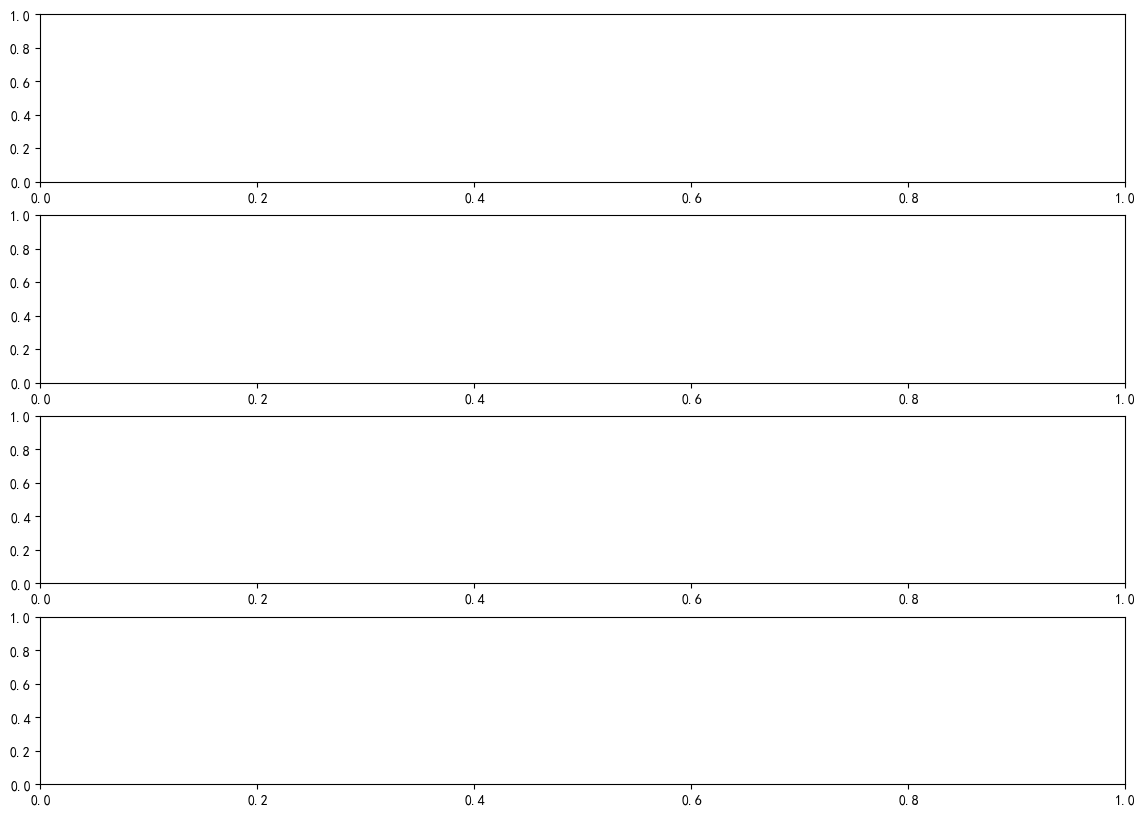

In [4]:
# 可视化信号流程
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# 参数说明：
# - 信源编码：每比特重复4次
# - 信道编码：每比特重复2次
# - 总编码：每原始比特变成 4*2=8 个编码比特
# - 接收信号采样数 = 128（channel_encoded长度）
# - 恢复原始16比特：需要从128个采样中每隔8个取1个

samples_per_encoded_bit = 1  # 每个编码比特对应1个采样点
total_encoded_bits = len(channel_encoded)  # = 128
decimation_factor = total_encoded_bits // num_bits  # = 128/16 = 8

# 1. 原始比特
ax1 = axes[0]
ax1.step(range(len(tx_bits)), tx_bits, 'b-', where='mid', linewidth=2)
ax1.set_ylabel('比特', fontsize=10)
ax1.set_title('发射端：信源比特流', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.2, 1.2)

# 2. 调制信号
ax2 = axes[1]
# 绘制发射信号前500个采样点
plot_samples = min(500, len(tx_signal))
ax2.plot(range(plot_samples), tx_signal[:plot_samples], 'b-', linewidth=1)
ax2.set_ylabel('幅度', fontsize=10)
ax2.set_title('发射端：调制后的射频信号', fontsize=12)
ax2.grid(True, alpha=0.3)

# 3. 接收信号（带噪声）
ax3 = axes[2]
ax3.plot(range(plot_samples), rx_signal[:plot_samples], 'r-', linewidth=1, alpha=0.7, label='接收信号')
ax3.plot(range(plot_samples), tx_signal[:plot_samples], 'b--', linewidth=1, alpha=0.5, label='原始信号')
ax3.set_ylabel('幅度', fontsize=10)
ax3.set_title('信道：信号在传输过程中叠加噪声', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 恢复比特（正确采样）
# 从接收信号恢复：每隔decimation_factor个采样取1个
recovered_signal = (rx_signal > 0).astype(int)
recovered_for_plot = recovered_signal[::decimation_factor][:num_bits]
ax4 = axes[3]
ax4.step(range(len(tx_bits)), tx_bits, 'b-', where='mid', linewidth=2, label='原始')
ax4.step(range(len(tx_bits)), recovered_for_plot, 'r--', where='mid', linewidth=2, label='恢复')
ax4.set_ylabel('比特', fontsize=10)
ax4.set_xlabel('采样点', fontsize=10)
ax4.set_title(f'接收端：恢复的比特流（每隔{decimation_factor}个采样取1个）', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim(-0.2, 1.2)

plt.tight_layout()
plt.show()

print("观察：")
print("1. 原始比特流通过调制变成射频信号")
print("2. 信道中的噪声使接收信号偏离原始信号")
print("3. 解调后可以恢复原始比特（假设噪声不大）")

## 4. 原理解析

### 4.1 通信系统的资源约束

任何通信系统都受到两大基本资源的约束：

**1. 带宽（Bandwidth）**
- 定义：信号频率成分的宽度，单位Hz
- 带宽决定了系统能够传输的最高频率（根据奈奎斯特采样定理）
- 带宽越宽，可传输的信息量越大（频谱效率↑）
- 频谱资源是有限的，需要政府分配和管理

**2. 功率（Power）**
- 发射功率决定了信号的覆盖范围
- 功率越大，信号在信道中传播更远
- 但功率受硬件限制，且增大功率会增加能耗和成本
- 接收功率必须高于噪声才能被正确检测

**香农公式**给出了在给定带宽和信噪比下的最大信息传输速率：

$$C = B \cdot \log_2(1 + \frac{S}{N})$$

其中：
- $C$：信道容量（bps）
- $B$：带宽（Hz）
- $S/N$：信噪比

In [ ]:
# 演示香农公式：信道容量与带宽/信噪比的关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 固定SNR=10dB，观察容量与带宽的关系
B = np.linspace(1, 1000, 1000)  # 带宽 Hz
SNR_db = 10
SNR = 10 ** (SNR_db / 10)
C = B * np.log2(1 + SNR)

ax1 = axes[0]
ax1.plot(B/1e6, C/1e6, 'b-', linewidth=2)
ax1.set_xlabel('带宽 B (MHz)', fontsize=11)
ax1.set_ylabel('信道容量 C (Mbps)', fontsize=11)
ax1.set_title(f'信道容量 vs 带宽 (SNR = {SNR_db} dB)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# 固定带宽=10MHz，观察容量与SNR的关系
B_fixed = 10e6  # 10 MHz
SNR_db_range = np.linspace(-10, 30, 100)
SNR_range = 10 ** (SNR_db_range / 10)
C2 = B_fixed * np.log2(1 + SNR_range)

ax2 = axes[1]
ax2.semilogy(SNR_db_range, C2/1e6, 'r-', linewidth=2)
ax2.set_xlabel('信噪比 SNR (dB)', fontsize=11)
ax2.set_ylabel('信道容量 C (Mbps)', fontsize=11)
ax2.set_title('信道容量 vs 信噪比 (B = 10 MHz)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("香农公式观察：")
print(f"1. 当SNR=10dB时，10MHz带宽的理论容量约为 {B_fixed/1e6*np.log2(1+SNR):.1f} Mbps")
print("2. 带宽每增加1倍，容量也增加1倍（线性关系）")
print("3. 信噪比对容量的影响更显著：SNR增加10dB，容量提升约3.3倍")

### 4.2 基本的性能指标

**1. 信噪比（SNR - Signal to Noise Ratio）**

信噪比是信号功率与噪声功率的比值：

$$SNR_{dB} = 10 \log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$

| SNR范围 | 通信质量 | 典型应用 |
|----------|----------|----------|
| > 20 dB | 优秀 | 光纤通信 |
| 10-20 dB | 良好 | 移动通信 |
| 0-10 dB | 一般 | 弱信号通信 |
| < 0 dB | 较差 | 噪声淹没信号 |

**2. 误码率（BER - Bit Error Rate）**

误码率是错误比特数与总传输比特数的比值：

$$BER = \frac{N_{error}}{N_{total}}$$

| BER要求 | 应用场景 |
|----------|----------|
| < 10^-3 | 语音通信 |
| < 10^-5 | 视频传输 |
| < 10^-8 | 数据通信 |
| < 10^-12 | 金融交易 |

**3. 频谱效率（ Spectral Efficiency）**

单位带宽能够传输的数据速率：

$$\eta = \frac{R}{B} \quad \text{(bit/s/Hz)}$$

其中R是数据速率，B是带宽。

In [ ]:
# 演示SNR与BER的关系
from scipy import special

def q_function(x):
    """Q函数：Q(x) = 0.5 * erfc(x / sqrt(2))"""
    return 0.5 * special.erfc(x / np.sqrt(2))

def ber_approximation(SNR_db):
    """
    简单调制（2ASK/BPSK）在AWGN信道下的近似BER
    实际系统中BER与调制方式、编码等相关
    """
    SNR = 10 ** (SNR_db / 10)
    # BPSK理论BER：Q(sqrt(2*SNR))
    return q_function(np.sqrt(2 * SNR))

# 计算不同SNR下的BER
SNR_range = np.linspace(-5, 20, 100)
ber_values = [ber_approximation(snr) for snr in SNR_range]

# 绘制SNR vs BER
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(SNR_range, ber_values, 'b-', linewidth=2, label='BPSK理论曲线')

ax.set_xlabel('信噪比 SNR (dB)', fontsize=12)
ax.set_ylabel('误码率 BER', fontsize=12)
ax.set_title('SNR与BER的关系（AWGN信道）', fontsize=14)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(-5, 20)
ax.set_ylim(1e-6, 1)

# 添加典型应用标注
ax.axhline(y=1e-3, color='g', linestyle='--', alpha=0.7, label='语音通信阈值')
ax.axhline(y=1e-5, color='r', linestyle='--', alpha=0.7, label='视频通信阈值')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("观察：")
print("1. SNR越高，BER越低（通信质量越好）")
print("2. 要达到BER=10^-3，需要约9.6dB的SNR")
print("3. 要达到BER=10^-5，需要约13dB的SNR")
print("4. 在SNR<0dB区域，BER接近0.5（随机判决）")

### 4.3 调制基础概念

**为什么要调制？**

调制是将信息加载到高频载波上的过程。无线通信需要调制的主要原因：

1. **频率搬移**：天线尺寸与波长成正比（$\lambda = c/f$），高频信号才能有效辐射
   - 300kHz信号需要约250m长的天线
   - 3GHz信号只需约2.5cm的天线

2. **频分复用**：不同用户使用不同频率，实现多用户同时通信

3. **抗干扰**：调制可以将信号置于噪声较小的频段

**基本调制方式**

| 调制方式 | 描述 | 特点 |
|----------|------|------|
| **AM** | 幅度调制 | 简单，但抗噪声差 |
| **FM** | 频率调制 | 抗噪声好，但占用带宽大 |
| **PM** | 相位调制 | 介于AM和FM之间 |
| **数字调制** | BPSK, QPSK, QAM等 | 频谱效率高，抗噪声能力强 |

In [ ]:
# 演示调制：将基带信号调制到载波上
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# 参数设置
fs = 1000   # 采样率
fc = 50     # 载波频率
t = np.linspace(0, 1, fs)

# 基带信号（低频信息）
baseband = np.sin(2 * np.pi * 2 * t)  # 2Hz低频信号

# 1. 原始基带信号
ax1 = axes[0]
ax1.plot(t, baseband, 'b-', linewidth=1.5)
ax1.set_ylabel('幅度', fontsize=10)
ax1.set_title('基带信号（待传输的信息）', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1.5, 1.5)

# 2. AM调制：幅度调制
carrier = np.sin(2 * np.pi * fc * t)
am_signal = (1 + 0.5 * baseband) * carrier
ax2 = axes[1]
ax2.plot(t, am_signal, 'r-', linewidth=1)
ax2.set_ylabel('幅度', fontsize=10)
ax2.set_title('AM调制（幅度调制）', fontsize=12)
ax2.grid(True, alpha=0.3)

# 3. FM调制：频率调制
# FM: 瞬时频率随基带信号变化
modulation_index = 2
fm_signal = np.sin(2 * np.pi * fc * t + modulation_index * np.cumsum(baseband) / fs)
ax3 = axes[2]
ax3.plot(t, fm_signal, 'g-', linewidth=1)
ax3.set_ylabel('幅度', fontsize=10)
ax3.set_title('FM调制（频率调制）', fontsize=12)
ax3.grid(True, alpha=0.3)

# 4. BPSK调制：相位键控
# 用0和pi相位表示比特
bits = np.array([0, 1, 0, 1, 1, 0, 0, 1])
bit_duration = len(t) // len(bits)
bpsk_signal = np.zeros(len(t))
for i, bit in enumerate(bits):
    phase = 0 if bit == 0 else np.pi
    start = i * bit_duration
    end = min((i+1) * bit_duration, len(t))
    bpsk_signal[start:end] = np.sin(2 * np.pi * fc * t[start:end] + phase)

ax4 = axes[3]
ax4.plot(t, bpsk_signal, 'm-', linewidth=1)
ax4.set_ylabel('幅度', fontsize=10)
ax4.set_xlabel('时间 (s)', fontsize=10)
ax4.set_title('BPSK调制（相位键控）', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("调制观察：")
print("1. 基带信号是低频的，无法直接通过天线有效辐射")
print("2. AM调制：载波幅度随基带信号变化")
print("3. FM调制：载波频率随基带信号变化")
print("4. BPSK调制：载波相位在0和π之间切换表示比特")

## 5. 思考题

1. **为什么无线通信需要调制？**
   - 如果直接发送基带信号会遇到什么问题？
   - 为什么高频信号更容易通过天线辐射？
   - 计算：如果要传输100MHz的基带信号，需要多长的天线（假设天线长度为波长的1/4）？

2. **5G相比4G的核心改进是什么？**
   - 从带宽、时延、连接密度等角度分析
   - 5G使用了哪些新技术来实现这些改进？

3. **香农公式的理解**
   - 如果带宽固定为20MHz，要达到1Gbps的速率，需要多大的信噪比？
   - 如果使用64-QAM调制（每符号6比特），实际能达到香农极限的多少比例？

4. **SNR与BER的关系**
   - 解释为什么在高SNR区域，SNR每增加3dB，误码率会大幅下降
   - 为什么在高噪声区域，继续增加发射功率效果有限？

5. **系统设计权衡**
   - 如果你设计一个物联网传感器网络，会优先考虑什么：功耗、距离还是带宽？
   - 如果设计一个高清视频传输系统呢？

6. **历史与技术演进**
   - 从莫尔斯电码到5G，通信技术的核心矛盾是什么？
   - 为什么说OTFS等新技术是为了解决传统OFDM的某些局限性？

---

## 总结

本notebook介绍了通信的基础知识：

- **通信基本定义**：信息从信源到信宿的传递过程
- **系统架构**：发射机 → 信道 → 接收机的完整链路
- **历史演进**：从烽火台到5G的漫长发展历程
- **资源约束**：带宽和功率是通信系统的两大基本资源
- **性能指标**：SNR、BER、频谱效率等关键指标
- **调制目的**：频率搬移、频分复用、抗干扰

这些基本概念为后续学习OTFS等先进通信技术奠定了基础。